In [1]:
import xarray as xr
import numpy as np
import glob as glob
import functions
import matplotlib.pyplot as plt
import seaborn as sns
import cmcrameri

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
# Definitions
Arctic_lim = 60
tslice = slice('2040-01-01','2069-12-31')
lons = slice(0,300)

In [35]:
# Load data clm data
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/land_vars/'
ds_piClim_clm = xr.open_dataset(rpath+'clm_piClim.nc')
ds_2xCO2_clm = xr.open_dataset(rpath+'clm_2xCO2.nc')
ds_4xCO2_clm = xr.open_dataset(rpath+'clm_4xCO2.nc')

# Select timeslice
ds_piClim_clm = ds_piClim_clm.sel(time=tslice)[['area','QFLX_EVAP_TOT', 'QSOIL','QVEGE','QVEGT']]
ds_2xCO2_clm = ds_2xCO2_clm.sel(time=tslice)[['area','QFLX_EVAP_TOT', 'QSOIL','QVEGE','QVEGT']]
ds_4xCO2_clm = ds_4xCO2_clm.sel(time=tslice)[['area','QFLX_EVAP_TOT', 'QSOIL','QVEGE','QVEGT']]

ds_clm = xr.concat([ds_piClim_clm, ds_2xCO2_clm, ds_4xCO2_clm], dim='co2_conc')
ds_clm = ds_clm.assign_coords({'co2_conc':['piClim', '2xCO2', '4xCO2']})

## Calculate spatial average

In [36]:
area_weights = ds_piClim_clm['area'].sel(lat=slice(Arctic_lim,90),lon=lons)/(ds_piClim_clm['area'].sel(lat=slice(Arctic_lim,90),lon=lons).sum())

ds_clm_avg = (ds_clm.sel(lat=slice(Arctic_lim, 90), lon=lons)*area_weights).sum(dim=['lon','lat'])

## Calculate monthly average

In [ ]:
ds_clm_m = ds_clm_avg.groupby(ds_clm_avg.time.dt.month).mean('time')

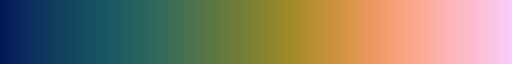

In [12]:
cmcrameri.cm.batlow

<>:20: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:20: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_3731639/1989533581.py:20: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  fig.suptitle('Evapotranspiration fluxes\nLand excluding Greenland > 60$^{\circ}$N', fontsize=18,fontweight='bold',y=0.7)


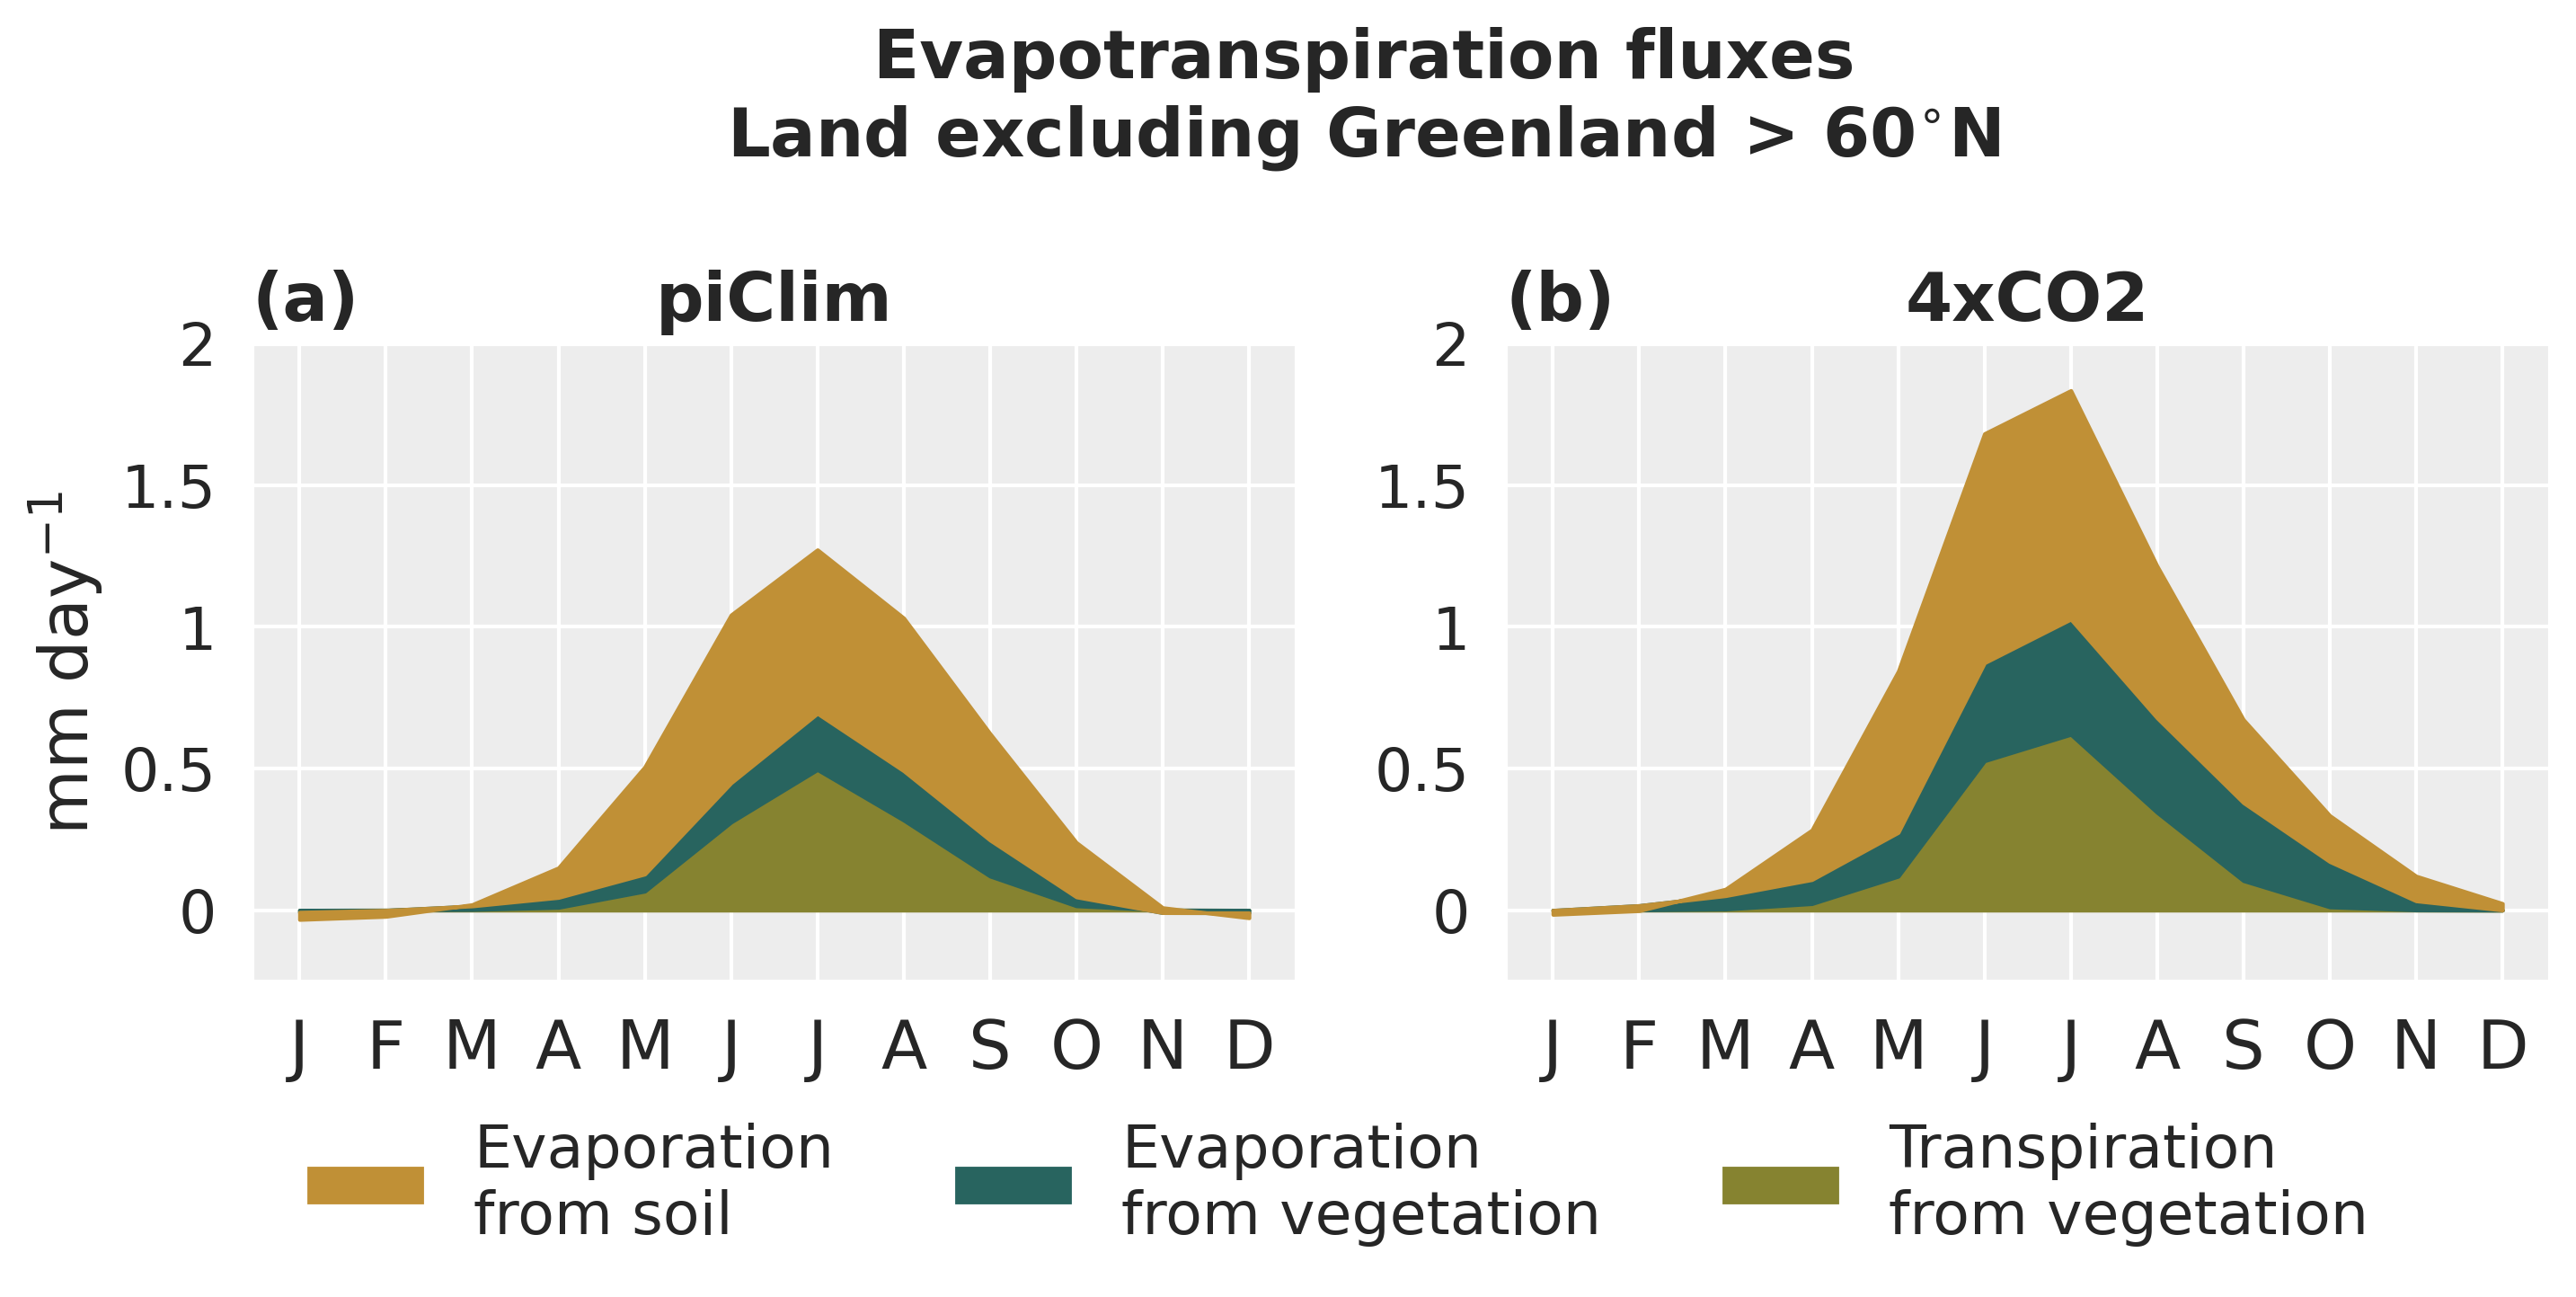

In [91]:
sns.set_theme()
sns.set_style('darkgrid', {'axes.facecolor':'.93'})

months = np.arange(1, 13, 1)
monthnames = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

# Colors
SOIL_color = cmcrameri.cm.batlow.colors[160]
VEGE_color = cmcrameri.cm.batlow.colors[70]
VEGT_color = cmcrameri.cm.batlow.colors[130]

var_list = ['QVEGT', 'QVEGE','QSOIL']
color_list = [VEGT_color, VEGE_color, SOIL_color]
conversion_factor = 60*60*24 # mm/s to mm/day

labels = [['(a)', '(b)']]
lw=3

fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(11, 6),dpi=300,constrained_layout=True)
fig.suptitle('Evapotranspiration fluxes\nLand excluding Greenland > 60$^{\circ}$N', fontsize=18,fontweight='bold',y=0.7)

for co2_conc, label in zip(['piClim', '4xCO2'], ['(a)', '(b)']):
    ax = axs[label]
    bottom_layer = np.zeros(12)
    for var, c in zip(var_list, color_list):

        data = ds_clm_m[var].sel(co2_conc=co2_conc)*conversion_factor
        ax.fill_between(months, bottom_layer, bottom_layer+data, color=c)
        bottom_layer = bottom_layer+data

        ax.set_title(co2_conc,fontsize=18,fontweight='bold')

        ax.set_ylim([-0.25,2])
        ax.set_yticks([0, 0.5, 1, 1.5, 2])
        ax.set_yticklabels([0, 0.5, 1, 1.5, 2], fontsize=16)
        if co2_conc == 'piClim':
            ax.set_ylabel('mm day$^{-1}$', fontsize=18)

        ax.set_xticks(months)
        ax.set_xticklabels(monthnames, fontsize=18)

        box = ax.get_position()
        ax.set_position([box.x0, box.y0,
                box.width, box.height * 0.8])


legend_elements = [Patch(facecolor=SOIL_color, edgecolor=None, label='Evaporation\nfrom soil'),
                     Patch(facecolor=VEGE_color, edgecolor=None, label='Evaporation\nfrom vegetation'),
                     Patch(facecolor=VEGT_color, edgecolor=None, label='Transpiration\nfrom vegetation')]

axs['(a)'].legend(handles=legend_elements, loc='lower left', bbox_to_anchor=(0, -0.5),frameon=False,
                fontsize=16, ncols=3)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/FigA8.png',bbox_inches='tight')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/FigA8.pdf',bbox_inches='tight')

plt.show()

In [ ]:
sns.set_theme()
sns.set_style('darkgrid', {'axes.facecolor':'.93'})

months = np.arange(1, 13, 1)
monthnames = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

# Colors

SM_color = cmcrameri.cm.glasgow.colors[70]
SC_color = cmcrameri.cm.glasgow.colors[200]

SRH_color = cmcrameri.cm.batlow.colors[160]
LCC_color = 'tab:blue'

ET_color = cmcrameri.cm.batlow.colors[170]
P_color = cmcrameri.cm.glasgow.colors[220]
R_color = cmcrameri.cm.glasgow.colors[100]

labels = [['(a)','(b)'],['(c)', ' ']]
lw=3

fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(13, 8),dpi=300,constrained_layout=True)

label = ' '
ax = axs[label]
ax.axis('off')

label_list = ['(a)', '(a)', '(c)', '(c)', '(b)', '(b)', '(b)']
var_list = ['FSOILSAT_20CM', 'FSNO', 'RELHUM', 'CLDLOW', 'PRECIP_TOTAL','QRUNOFF','QFLX_EVAP_TOT']
color_list = [SM_color, SC_color, SRH_color, LCC_color, P_color, R_color, ET_color]

axs['(a)'].set_title('Land reservoirs', fontsize=18,fontweight='bold')
axs['(b)'].set_title('Fluxes', fontsize=18,fontweight='bold')
axs['(a)'].set_title('Atmospheric reservoirs', fontsize=18,fontweight='bold')


for label, var, c in zip(label_list, var_list, color_list):
    ax = axs[label]
    for ds, ds_std, ls in zip([ds_piClim_m, ds_4xCO2_m], [ds_piClim_std, ds_4xCO2_std], ['-','--']):

        if var in ['FSOILSAT_20CM', 'FSNO', 'CLDLOW']:
            data = ds[var]*100 # Convert to percent
            std = ds_std[var]*100
        elif var in ['PRECIP_TOTAL','QRUNOFF','QFLX_EVAP_TOT']:
            data = ds[var]*60*60*24 # Convert to mm/day
            std = ds_std[var]*60*60*24
        ax.plot(months, data, color=c, linestyle=ls, lw=lw,zorder=10)
        ax.fill_between(months, data-std, data+std, color=c, alpha=0.5)
        
    ax.set_title(title, fontsize=18,fontweight='bold')

    if var in ['PRECIP_TOTAL','QRUNOFF','QFLX_EVAP_TOT']:
        ax.set_ylim([-0.25,3.25])
        ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5, 3])
        ax.set_yticklabels([0, '', 1, '', 2, '', 3], fontsize=18)
        #ax.tick_params(axis='y', length=0.00001)
        ax.set_ylabel('mm day$^{-1}$', fontsize=18)
    else:
        ax.set_ylim([-10,110])
        ax.set_yticks([0, 20, 40, 60, 80, 100])
        ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=18)
        ax.set_ylabel('%', fontsize=18)

    ax.set_xticks(months)
    ax.set_xticklabels(monthnames, fontsize=18)




# (a)
label = '(a)'
ax = axs[label]
for ds, name, ls in zip([ds_piClim_m, ds_4xCO2_m], ['piClim', '4xCO2'],['-','--']):

# Soil saturation and snow cover
    for var, c in zip(['FSOILSAT_20CM', 'FSNO'], [SM_color, SC_color]):
        data = ds[var]*100 # Convert to percent
        ax.plot(months, data, color=c, linestyle=ls, lw=lw,zorder=10)
    
ax.set_title('Land reservoirs', fontsize=18,fontweight='bold')
ax.set_ylim([-10,110])
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=18)
ax.set_ylabel('%', fontsize=18)
ax.set_xticks(months)
ax.set_xticklabels(monthnames, fontsize=18)

# (b))
label = '(b)'
ax = axs[label]
for ds, name, ls in zip([ds_piClim_m, ds_4xCO2_m], ['piClim', '4xCO2'],['-','--']):
    # For flux variables
    for var, c in zip(['QFLX_EVAP_TOT', 'QRUNOFF','PRECIP_TOTAL'], [ET_color, R_color,P_color]):
        data = ds[var]*60*60*24 # Convert to mm/day
        ax.plot(months, data, color=c, linestyle=ls, lw=lw,zorder=10)
    
ax.set_title('Fluxes', fontsize=18,fontweight='bold')
ax.set_ylim([-0.25,3.25])
ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5, 3])
ax.set_yticklabels([0, '', 1, '', 2, '', 3], fontsize=18)
ax.tick_params(axis='y', length=0.00001)
ax.set_ylabel('mm day$^{-1}$', fontsize=18)
ax.set_xticks(months)
ax.set_xticklabels(monthnames, fontsize=18)


# (c)
label = '(c)'
ax = axs[label]

 # Surface relative humidity and clouds
for ds, name, ls in zip([ds_piClim_m, ds_4xCO2_m], ['piClim', '4xCO2'],['-','--']):
    for var, c in zip(['RELHUM','CLDLOW'], [SRH_color,LCC_color]):
        if var == 'CLDLOW':
            data = ds[var]*100 # Convert to percent
        else:
            data = ds[var]
        ax.plot(months, data, color=c, linestyle=ls, lw=lw,zorder=10)

ax.set_title('Atmospheric reservoirs', fontsize=18,fontweight='bold')
ax.set_ylim([-10,110])
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels([0, 20, 40, 60, 80, 100], fontsize=18)
ax.set_ylabel('%', fontsize=18)
ax.set_xticks(months)
ax.set_xticklabels(monthnames, fontsize=18)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements_0 = [Line2D([0], [0], color='darkgrey', lw=lw, linestyle='-', label='piClim'),
                Line2D([0], [0], color='darkgrey', lw=lw, linestyle='--', label='4xCO$_2$'),]


legend_elements_1 = [Line2D([0], [0], color=SC_color, lw=lw, linestyle='-', label='Snow cover'),
                Line2D([0], [0], color=SM_color, lw=lw, linestyle='-', label='Surface\nsoil moisture\nsaturation')]

legend_elements_2 = [Line2D([0], [0], color=ET_color, lw=lw, linestyle='-', label='Evapotranspiration'),
                   Line2D([0], [0], color=P_color, lw=lw, linestyle='-', label='Precipitation'),
                   Line2D([0], [0], color=R_color, lw=lw, linestyle='-', label='Runoff')]

legend_elements_3 = [Line2D([0], [0], color=SRH_color, lw=lw, linestyle='-', label='Near-surface\nrelative humidity'),
                Line2D([0], [0], color=LCC_color, lw=lw, linestyle='-', alpha=0.5,label='Low cloud cover')]

legend_elements_all = [
                Patch(visible=False,label= '(a)'),
                Line2D([0], [0], color=SC_color, lw=lw, linestyle='-', label='Snow cover'),
                Line2D([0], [0], color=SM_color, lw=lw, linestyle='-', label='Surface\nsoil moisture\nsaturation'),
                Patch(visible=False,label= ' '),
                Patch(visible=False,label= '(c)'),
                Line2D([0], [0], color=SRH_color, lw=lw, linestyle='-', label='Near-surface\nrelative humidity'),
                Line2D([0], [0], color=LCC_color, lw=lw, linestyle='-', alpha=0.5,label='Low cloud cover'),
                Patch(visible=False,label= '(b)'),
                Line2D([0], [0], color=ET_color, lw=lw, linestyle='-', label='Evapo-\ntranspiration'),
                Line2D([0], [0], color=P_color, lw=lw, linestyle='-', label='Precipitation'),
                Line2D([0], [0], color=R_color, lw=lw, linestyle='-', label='Runoff'),
                Patch(visible=False,label= ' '),
                Patch(visible=False,label= ' '),]

ax1 = axs['(b)'].twinx()
ax1.legend(handles=legend_elements_0, loc='upper left', bbox_to_anchor=(0.68, 1.30),frameon=False,
                fontsize=18,title_fontsize=18)
ax1.get_yaxis().set_visible(False)

axs[' '].legend(handles=legend_elements_all, loc='upper left', bbox_to_anchor=(-0.1, 1.1),frameon=False,
                fontsize=16,title_fontsize=16,ncols=2)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=18,fontweight='bold')
fig.suptitle('Land excluding Greenland, latitudes > 60$^{\circ}$N',fontsize=20,fontweight='bold')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig3.png',bbox_inches='tight')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/Fig3.pdf',bbox_inches='tight')

plt.show()